<a href="https://colab.research.google.com/github/sanchezduvanricardo/AnalisisDatosUNAD/blob/main/hierarchical_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

**1. Análisis exploratorio de los datos (EDA)**

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  

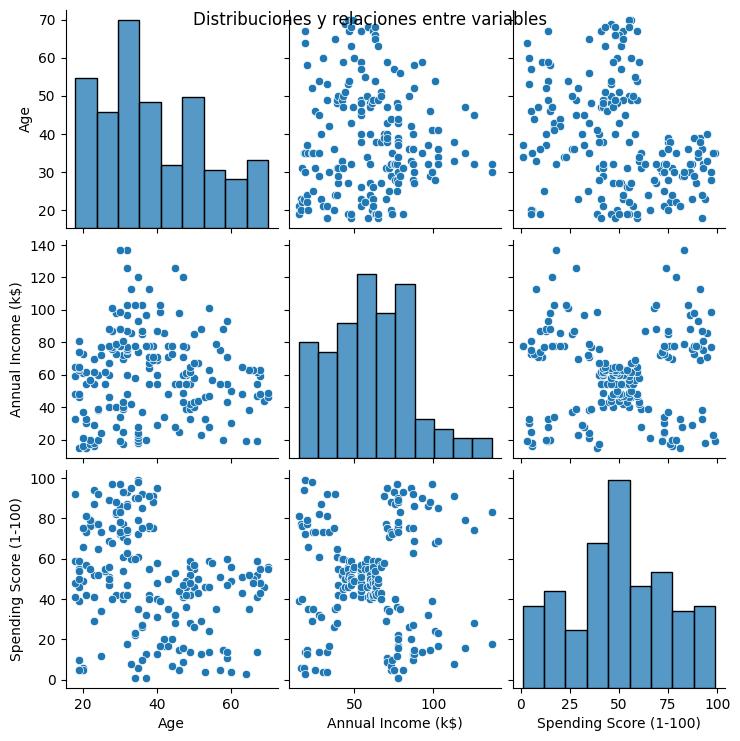

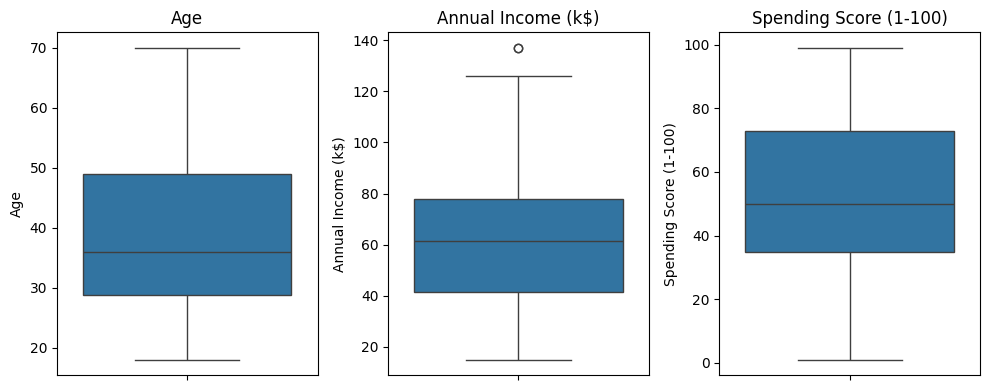

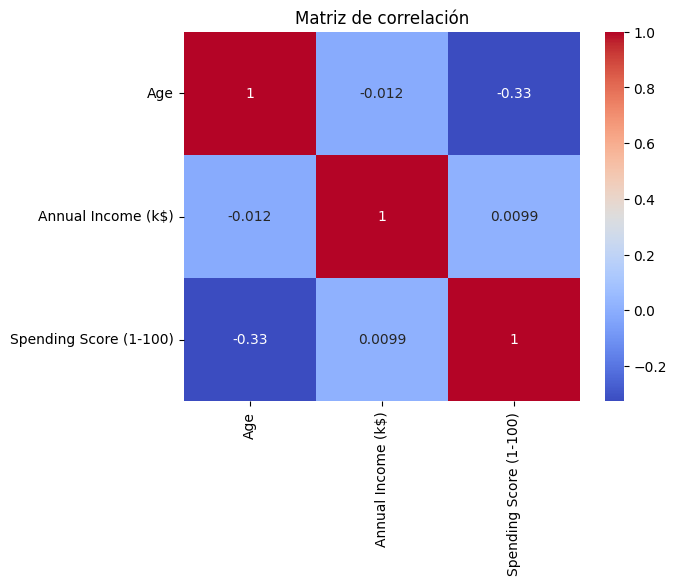

In [30]:
# Cargar dataset
df = pd.read_csv('Mall_Customers.csv')

# Vista general
print(df.head())
print(df.info())
print(df.describe())

# Visualizar distribuciones
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.suptitle("Distribuciones y relaciones entre variables")
plt.show()

# Boxplots para ver outliers
plt.figure(figsize=(10, 4))
for i, col in enumerate(['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Correlación
sns.heatmap(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()


**2. Preprocesamiento de datos**

In [31]:
# Convertir género a numérico si se desea usar (opcional)
# df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Seleccionar solo variables numéricas relevantes
df_selected = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Imputación (aunque en este dataset no hay valores faltantes)
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df_selected), columns=df_selected.columns)

# Escalar datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_imputed)


**3. Selección de características**

In [32]:
# Ya están seleccionadas directamente como numéricas principales
# Opcional: aplicar PCA para análisis de varianza o reducción de dimensiones
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
print(f"Varianza explicada por PCA: {pca.explained_variance_ratio_}")


Varianza explicada por PCA: [0.44266167 0.33308378]


**4. Entrenamiento del modelo - Clustering Jerárquico**

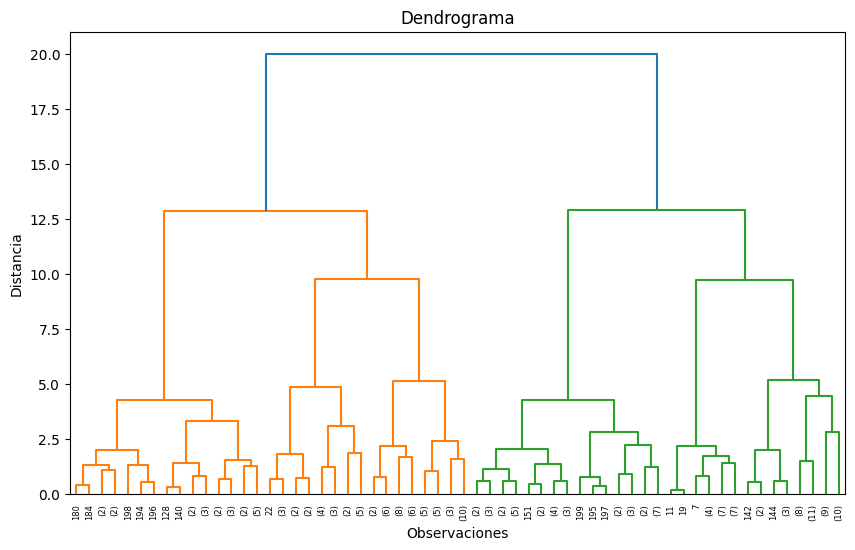

In [33]:
# Crear matriz de linkage
linkage_matrix = linkage(df_scaled, method='ward')  # 'ward' minimiza varianza intra-cluster

# Dendrograma
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title("Dendrograma")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()

# Asignar clusters
n_clusters = 6
cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')


**5. Evaluación del modelo**

In [34]:
sil_score = silhouette_score(df_scaled, cluster_labels)
calinski_score = calinski_harabasz_score(df_scaled, cluster_labels)

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Calinski-Harabasz Index: {calinski_score:.3f}")


Silhouette Score: 0.420
Calinski-Harabasz Index: 127.986


**6. Visualización de resultados**

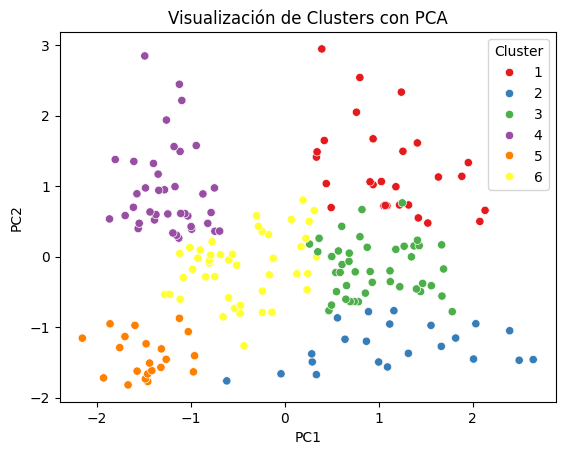

Resumen por cluster:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
1        43.892857           91.285714               16.678571
2        44.318182           25.772727               20.272727
3        56.400000           55.288889               48.355556
4        32.692308           86.538462               82.128205
5        24.809524           25.619048               80.238095
6        27.377778           57.511111               45.844444


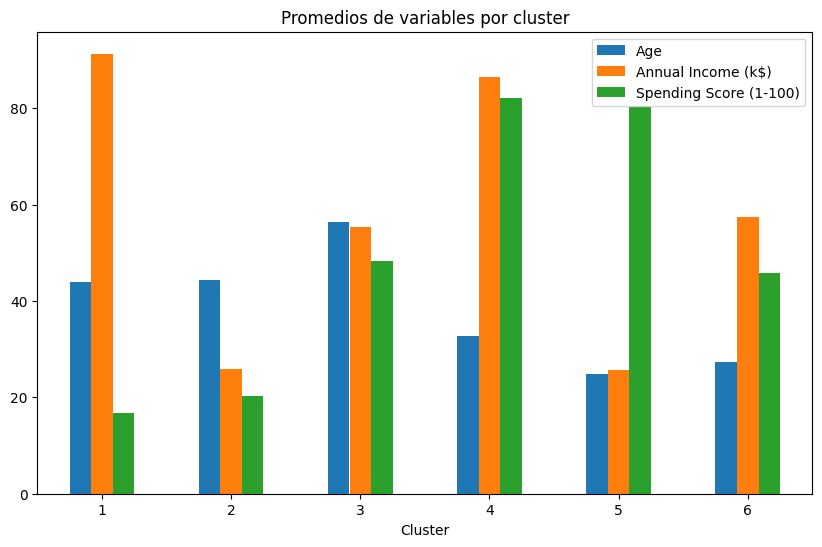

In [35]:
# Visualización en espacio PCA
df_result = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_result['Cluster'] = cluster_labels

sns.scatterplot(data=df_result, x='PC1', y='PC2', hue='Cluster', palette='Set1')
plt.title("Visualización de Clusters con PCA")
plt.show()

# Visualización de perfiles de clientes por cluster
df_profile = df_imputed.copy()
df_profile['Cluster'] = cluster_labels
cluster_summary = df_profile.groupby('Cluster').mean()

print("Resumen por cluster:")
print(cluster_summary)

cluster_summary.plot(kind='bar', figsize=(10,6))
plt.title("Promedios de variables por cluster")
plt.xticks(rotation=0)
plt.show()


**7. Interpretación y documentación**

Se identificaron 6 clusters distintos según edad, ingreso anual y gasto.

- **Cluster 1:** Personas de edad media, con altos ingresos pero bajo gasto.

- **Cluster 2:** Personas de edad media, con ingresos bajos y bajo gasto.

- **Cluster 3:** Clientes mayores, con ingresos medios y gasto moderado.

- **Cluster 4:** Jóvenes con altos ingresos y alto gasto.

- **Cluster 5:** Jóvenes con ingresos bajos a medios pero alto gasto.

- **Cluster 6:** Jóvenes con ingresos medios y gasto moderado.

**Silhouette Score:** 0.420, lo que indica una buena separación entre los clusters.

**Índice Calinski-Harabasz:** 127.986, lo que indica buena separación y cohesión interna de los clusters.

Este análisis puede ayudar al centro comercial a personalizar estrategias de marketing dirigidas a cada grupo, como promociones especiales para los grupos con alto poder adquisitivo (Clusters 4 y 5) o descuentos para los grupos con menor gasto (Clusters 2 y 6).


